# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Armon Haji

**Date:** 9/6/2026

In [ ]:
# Your Phase 1 solution to the problem goes here.


In [1]:
import pandas as pd

airbnb = pd.read_csv("./data/airbnb_hw.csv")
airbnb.head()

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


In [3]:
airbnb["Price"].head(20)

0     145
1      37
2      28
3     199
4     549
5     149
6     250
7      90
8     270
9     290
10    170
11     59
12     49
13     68
14    285
15     75
16    145
17    100
18    150
19    700
Name: Price, dtype: str

In [5]:
airbnb["Price"] = airbnb["Price"].str.replace(",", "")
airbnb["Price"] = pd.to_numeric(airbnb["Price"])
airbnb["Price"].isna().sum()

0

In [9]:
## Some of the prices included commas. I removed the commas to turn them into pure numeric form and I got 0 missing values.

In [11]:
police = pd.read_csv("./data/mn_police_use_of_force.csv")
police["subject_injury"].value_counts(dropna=False)

subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64

In [13]:
police["subject_injury"].isna().mean()

0.7619342359767892

In [15]:
pd.crosstab(
    police["force_type"],
    police["subject_injury"].fillna("Missing")
)

subject_injury,Missing,No,Yes
force_type,,,
Baton,2,0,2
Bodily Force,7051,1093,1286
Chemical Irritant,1421,131,41
Firearm,0,2,0
Gun Point Display,27,33,44
Improvised Weapon,74,34,40
Less Lethal,87,0,0
Less Lethal Projectile,0,1,2
Maximal Restraint Technique,170,0,0


In [ ]:
## We can see that about 76% of the subject injury values are missing which is definitely a big concern for us. 
# It differs among data type. Firearm has none missing, but Less Lethal and Maximal
# Restraint Technique are all missing.

In [ ]:
## Now moving to Q2

In [19]:
sharks = pd.read_excel("./data/GSAF5.xls")
sharks.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
sharks = sharks.dropna(axis=1, how="all")
sharks.shape

(7117, 23)

In [23]:
sharks["Year"] = pd.to_numeric(sharks["Year"])
sharks["Year"].min(), sharks["Year"].max()

(0.0, 2026.0)

In [ ]:
# The year value ranges from 0 to 2026. This is an issue because 0 seems not likely.

In [27]:
sharks_1940 = sharks[sharks["Year"] > 1940]

<Axes: xlabel='Year'>

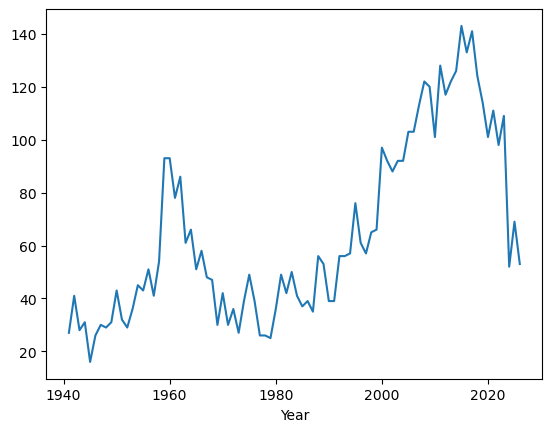

In [29]:
sharks_1940["Year"].value_counts().sort_index().plot()

In [ ]:
## It appears that there were spikes around 1950-1960 and 2000-2010. There were a lot of ups and downs
## but it generally increased over time.

In [31]:
sharks_1940["Age"].value_counts(dropna=False).head(20)

Age
NaN    1763
16       80
19       80
17       77
15       76
20       73
18       73
17       71
20       67
15       65
25       65
21       64
22       63
18       62
24       58
19       57
14       57
16       56
21       56
14       52
Name: count, dtype: int64

<Axes: >

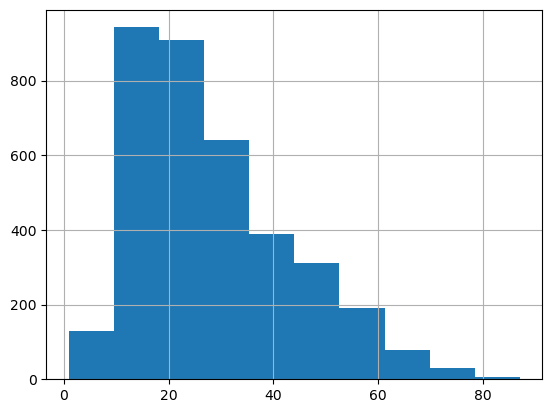

In [35]:
age_clean = sharks_1940["Age"].astype(str)
age_clean = age_clean[age_clean.str.isdigit()].astype(int)
age_clean.hist()

In [37]:
sharks_1940["Sex"].value_counts(dropna=False)

Sex
M        4367
F         727
NaN       447
M           7
?           2
F           2
M F         1
 M          1
m           1
lli         1
M x 2       1
Name: count, dtype: int64

In [39]:
known_sex = sharks_1940[sharks_1940["Sex"].isin(["M", "F"])]
(known_sex["Sex"] == "M").mean()

0.8572830781311347

In [ ]:
## The proportion of victims which are male is 85.7% 

In [41]:
sharks_1940["Type"].value_counts(dropna=False)

Type
Unprovoked             4143
Provoked                525
Invalid                 399
Watercraft              278
Sea Disaster            156
Questionable             27
NaN                      14
Boat                      7
 Provoked                 2
UNprovoked                1
unprovoked                1
?                         1
Unconfirmed               1
Unverified                1
Under investigation       1
Name: count, dtype: int64

In [43]:
sharks_1940["Type_clean"] = "Unknown"

sharks_1940.loc[sharks_1940["Type"] == "Provoked", "Type_clean"] = "Provoked"
sharks_1940.loc[sharks_1940["Type"] == "Unprovoked", "Type_clean"] = "Unprovoked"

sharks_1940["Type_clean"].value_counts()

Type_clean
Unprovoked    4143
Unknown        889
Provoked       525
Name: count, dtype: int64

In [45]:
4143/5557

0.7455461579989203

In [ ]:
# Around 74.5% of attacks are unprovoked.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]